In [15]:
import pandas as pd

train_df = pd.read_csv(r"C:\Users\samaira\Downloads\Synergy_TP_repo\task_12\data\datatraining.txt")
test1_df = pd.read_csv(r"C:\Users\samaira\Downloads\Synergy_TP_repo\task_12\data\datatest.txt")
test2_df = pd.read_csv(r"C:\Users\samaira\Downloads\Synergy_TP_repo\task_12\data\datatest2.txt")

for name, df in [("train", train_df), ("test1", test1_df), ("test2", test2_df)]:
    print(name, df.shape)

train_df.head()

train (8143, 7)
test1 (2665, 7)
test2 (9752, 7)


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


In [16]:
for df in [train_df, test1_df, test2_df]:
    df["date"] = pd.to_datetime(df["date"])

for name, df in [("train", train_df), ("test1", test1_df), ("test2", test2_df)]:
    print(name)
    print(" date range:", df["date"].min(), "to", df["date"].max())
    print(" occupancy balance:\n", df["Occupancy"].value_counts(normalize=True))
    print()

train
 date range: 2015-02-04 17:51:00 to 2015-02-10 09:33:00
 occupancy balance:
 Occupancy
0    0.78767
1    0.21233
Name: proportion, dtype: float64

test1
 date range: 2015-02-02 14:19:00 to 2015-02-04 10:43:00
 occupancy balance:
 Occupancy
0    0.635272
1    0.364728
Name: proportion, dtype: float64

test2
 date range: 2015-02-11 14:48:00 to 2015-02-18 09:19:00
 occupancy balance:
 Occupancy
0    0.789889
1    0.210111
Name: proportion, dtype: float64



In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

full_df = pd.concat([train_df, test1_df, test2_df], ignore_index=True)
features = ["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]

X_full = full_df[features]
y_full = full_df["Occupancy"]

X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

rf_random = RandomForestClassifier(n_estimators=200, random_state=42)
rf_random.fit(X_tr, y_tr)
pred_random = rf_random.predict(X_te)

print("Random split — Accuracy:", accuracy_score(y_te, pred_random))
print("Random split — F1:", f1_score(y_te, pred_random))

Random split — Accuracy: 0.9907587548638133
Random split — F1: 0.9801047120418848


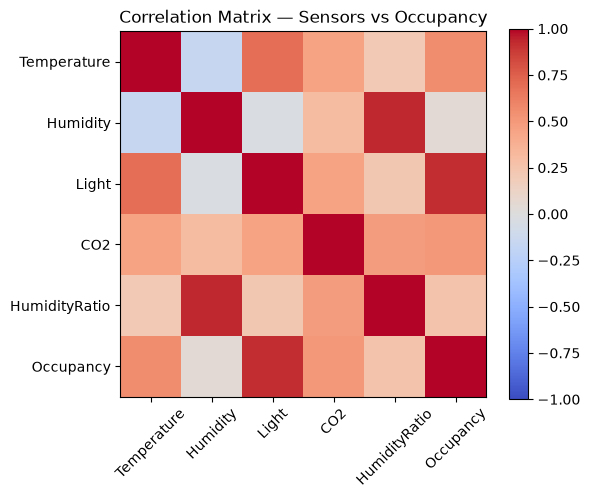

In [18]:
import matplotlib.pyplot as plt

corr = full_df[features + ["Occupancy"]].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix — Sensors vs Occupancy")
plt.tight_layout()
plt.savefig("../output/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
X_train_real = train_df[features]
y_train_real = train_df["Occupancy"]
X_test_real = test2_df[features]
y_test_real = test2_df["Occupancy"]

rf_real = RandomForestClassifier(n_estimators=200, random_state=42)
rf_real.fit(X_train_real, y_train_real)
pred_real = rf_real.predict(X_test_real)

print("Realistic split (test2) — Accuracy:", accuracy_score(y_test_real, pred_real))
print("Realistic split (test2) — F1:", f1_score(y_test_real, pred_real))

Realistic split (test2) — Accuracy: 0.9728260869565217
Realistic split (test2) — F1: 0.9379826819564708


In [20]:
X_test1 = test1_df[features]
y_test1 = test1_df["Occupancy"]

pred_test1 = rf_real.predict(X_test1)  # reuse the model trained on train_df

print("Condition-shift (train test1, door-open) — Accuracy:", accuracy_score(y_test1, pred_test1))
print("Condition-shift (train test1, door-open) — F1:", f1_score(y_test1, pred_test1))

Condition-shift (train test1, door-open) — Accuracy: 0.949343339587242
Condition-shift (train test1, door-open) — F1: 0.9293563579277865


In [21]:
import numpy as np

# Repeated random splits
random_scores = []
for seed in range(5):
    X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.2, random_state=seed, stratify=y_full)
    m = RandomForestClassifier(n_estimators=200, random_state=seed)
    m.fit(X_tr, y_tr)
    random_scores.append(f1_score(y_te, m.predict(X_te)))

print("Random split F1 — mean:", np.mean(random_scores), "std:", np.std(random_scores))
print(random_scores)

Random split F1 — mean: 0.984484422583231 std: 0.0031864854494608533
[0.9868766404199475, 0.988976377952756, 0.980083857442348, 0.9821428571428571, 0.9843423799582464]


In [22]:
realistic_scores = []
for seed in range(5):
    m = RandomForestClassifier(n_estimators=200, random_state=seed)
    m.fit(X_train_real, y_train_real)
    realistic_scores.append(f1_score(y_test_real, m.predict(X_test_real)))

print("Realistic split F1 — mean:", np.mean(realistic_scores), "std:", np.std(realistic_scores))
print(realistic_scores)

Realistic split F1 — mean: 0.9387931952592664 std: 0.009836888747750433
[0.9400836042731073, 0.9201520912547528, 0.9399309551208286, 0.9478850198644543, 0.9459143057831889]


In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

full_df["cluster"] = cluster_labels
print(full_df.groupby("cluster")["Occupancy"].value_counts(normalize=True))

cluster  Occupancy
0        0            0.981687
         1            0.018313
1        1            0.694067
         0            0.305933
Name: proportion, dtype: float64


In [24]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso.fit(X_scaled)  # same scaled features as K-Means, still no Occupancy column

anomaly_pred = iso.predict(X_scaled)  # returns 1 = normal, -1 = anomaly
full_df["anomaly"] = anomaly_pred

print(full_df["anomaly"].value_counts())

anomaly
 1    19533
-1     1027
Name: count, dtype: int64


In [25]:
print(full_df.groupby("anomaly")["Occupancy"].value_counts(normalize=True))

anomaly  Occupancy
-1       1            0.561831
         0            0.438169
 1       0            0.786362
         1            0.213638
Name: proportion, dtype: float64


In [26]:
for c in [0.02, 0.05, 0.10]:
    iso_c = IsolationForest(n_estimators=200, contamination=c, random_state=42)
    iso_c.fit(X_scaled)          # <-- this line was missing
    pred_c = iso_c.predict(X_scaled)
    
    n_anomalies = (pred_c == -1).sum()
    occ_rate_in_anomalies = full_df.loc[pred_c == -1, "Occupancy"].mean()
    
    print(f"contamination={c}: {n_anomalies} flagged anomalies, "
          f"{occ_rate_in_anomalies:.3f} occupied-rate among them")

contamination=0.02: 412 flagged anomalies, 0.752 occupied-rate among them
contamination=0.05: 1027 flagged anomalies, 0.562 occupied-rate among them
contamination=0.1: 2056 flagged anomalies, 0.610 occupied-rate among them


In [27]:
# Reuse rf_real (trained on train_df, tested cleanly on test2_df already)

# Corrupt test2 only — simulate CO2 sensor failure by replacing it with the training mean
X_test_corrupted = X_test_real.copy()
X_test_corrupted["CO2"] = X_train_real["CO2"].mean()  # sensor "stuck" at a constant fallback value

pred_corrupted = rf_real.predict(X_test_corrupted)

print("Clean test2 — Accuracy:", accuracy_score(y_test_real, pred_real))
print("Clean test2 — F1:", f1_score(y_test_real, pred_real))
print("CO2-failure test2 — Accuracy:", accuracy_score(y_test_real, pred_corrupted))
print("CO2-failure test2 — F1:", f1_score(y_test_real, pred_corrupted))

Clean test2 — Accuracy: 0.9728260869565217
Clean test2 — F1: 0.9379826819564708
CO2-failure test2 — Accuracy: 0.9884126333059885
CO2-failure test2 — F1: 0.972645848462842


In [28]:
print("CO2 — train mean/std:", X_train_real["CO2"].mean(), X_train_real["CO2"].std())
print("CO2 — test2 mean/std:", X_test_real["CO2"].mean(), X_test_real["CO2"].std())

CO2 — train mean/std: 606.5462431945639 314.32087688106805
CO2 — test2 mean/std: 753.2248316584632 297.09611361144437


In [29]:
importances = pd.Series(rf_real.feature_importances_, index=features)
print(importances.sort_values(ascending=False))

Light            0.620356
CO2              0.232947
Temperature      0.088687
HumidityRatio    0.031733
Humidity         0.026277
dtype: float64


In [30]:
import os
os.makedirs("../output", exist_ok=True)

# 1. Split comparison table
split_results = pd.DataFrame([
    {"split": "Random (naive)", "accuracy": 0.9908, "f1": 0.9801},
    {"split": "Realistic - future days (test2)", "accuracy": 0.9728, "f1": 0.9380},
    {"split": "Realistic - condition shift (test1)", "accuracy": 0.9493, "f1": 0.9294},
])
split_results.to_csv("../output/split_comparison.csv", index=False)

# 2. Stability results
stability_results = pd.DataFrame({
    "seed": range(5),
    "random_split_f1": random_scores,
    "realistic_split_f1": realistic_scores,
})
stability_results.to_csv("../output/stability_repeats.csv", index=False)

# 3. Contamination sensitivity
contamination_results = pd.DataFrame([
    {"contamination": 0.02, "n_flagged": 412, "occupied_rate": 0.752},
    {"contamination": 0.05, "n_flagged": 1027, "occupied_rate": 0.562},
    {"contamination": 0.10, "n_flagged": 2056, "occupied_rate": 0.610},
])
contamination_results.to_csv("../output/contamination_sensitivity.csv", index=False)

# 4. Robustness stress test
robustness_results = pd.DataFrame([
    {"condition": "Clean test2", "accuracy": 0.9728, "f1": 0.9380},
    {"condition": "CO2-failure (flattened)", "accuracy": 0.9884, "f1": 0.9726},
])
robustness_results.to_csv("../output/robustness_stress_test.csv", index=False)

# 5. Feature importances
importances.sort_values(ascending=False).to_csv("../output/feature_importances.csv")

print("All result files saved.")

All result files saved.


In [31]:
full_df.groupby("cluster")["Occupancy"].value_counts(normalize=True).to_csv("../output/kmeans_crosstab.csv")
full_df.groupby("anomaly")["Occupancy"].value_counts(normalize=True).to_csv("../output/isolationforest_crosstab.csv")

In [32]:
import joblib

joblib.dump(rf_real, "../model/final_occupancy_model.joblib")

['../model/final_occupancy_model.joblib']